In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/airline_booking.csv', encoding='latin-1')

In [ ]:
df.head(1)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0


In [ ]:
df.tail(0)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete


In [ ]:
df.shape

(50000, 14)

In [ ]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

In [ ]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype in ['object', 'bool']:
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 10:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [ ]:
categorical, non_categorical, discrete, continuous = classify_features(df)

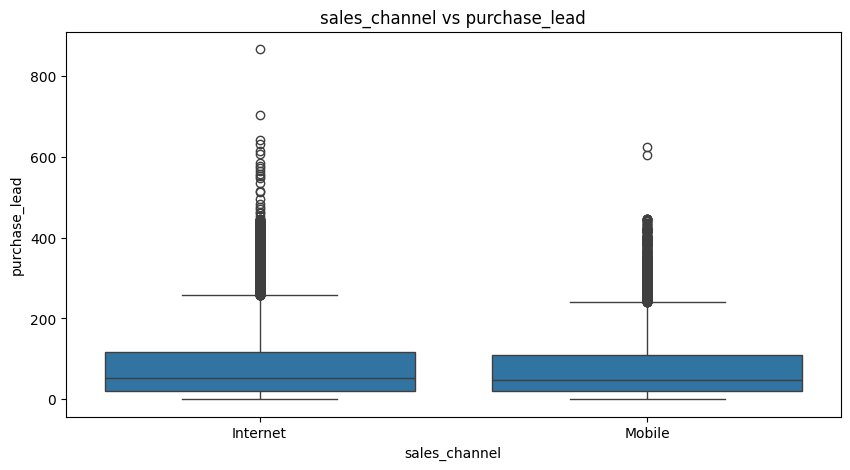

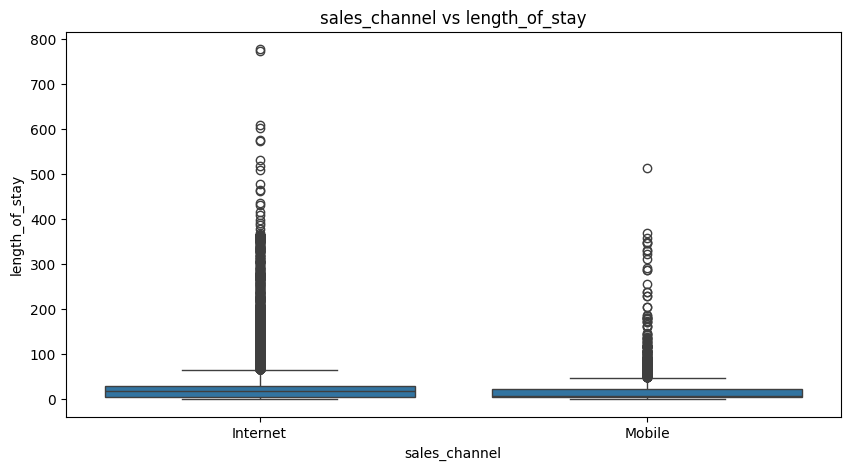

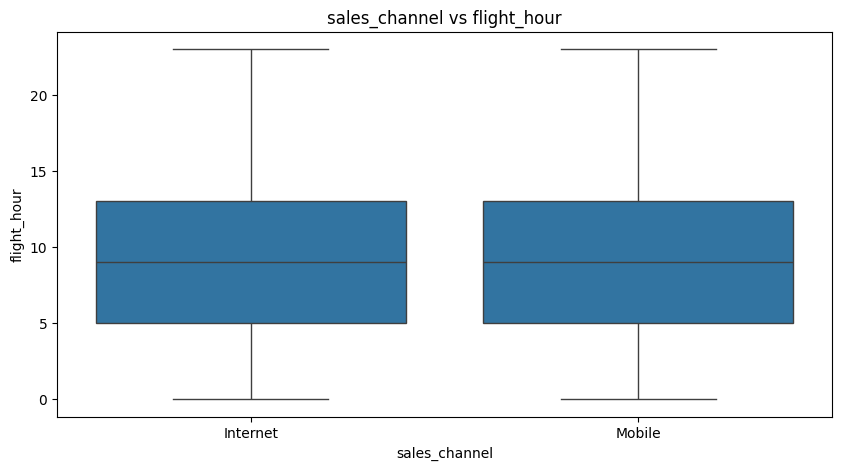

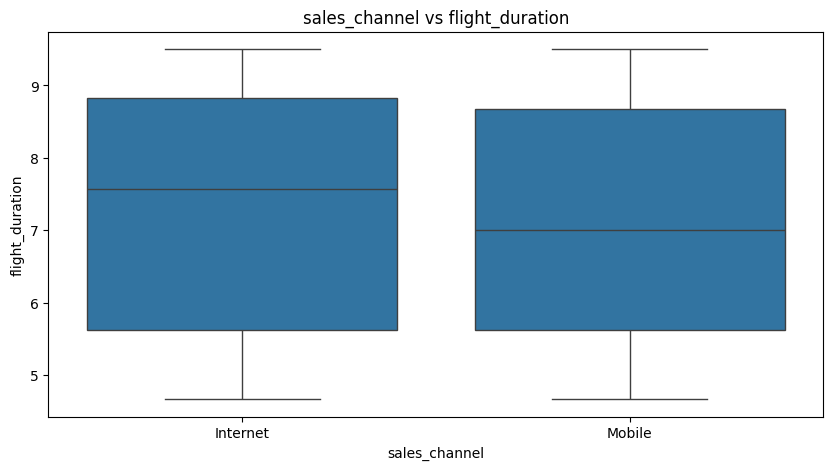

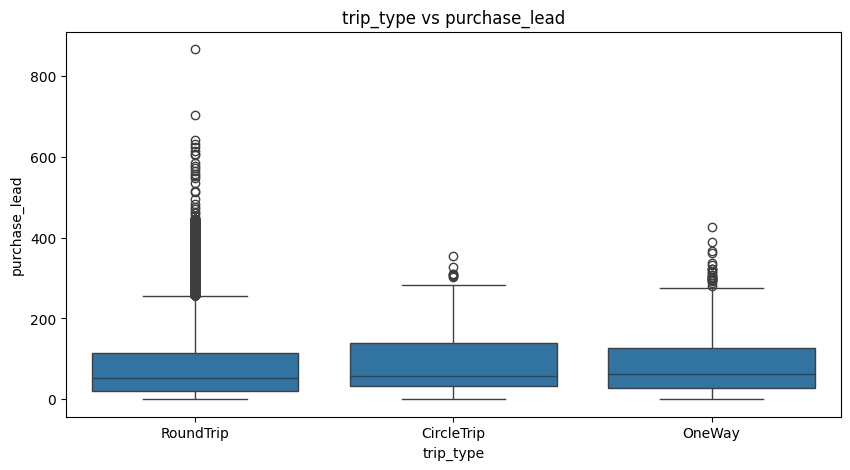

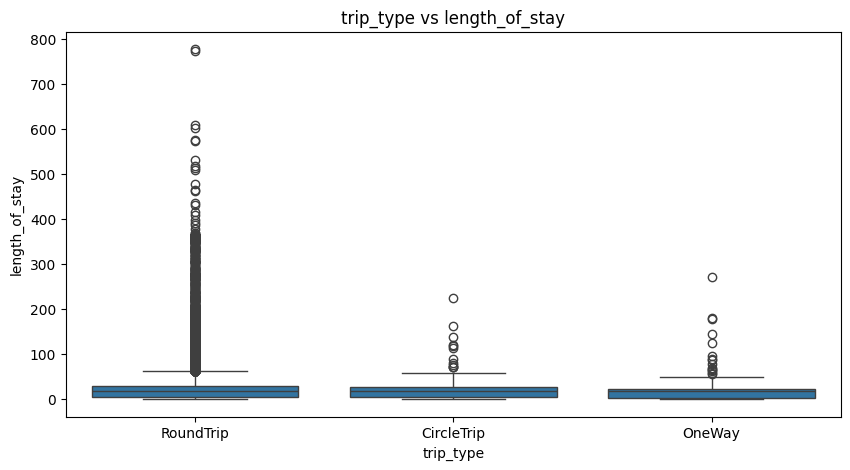

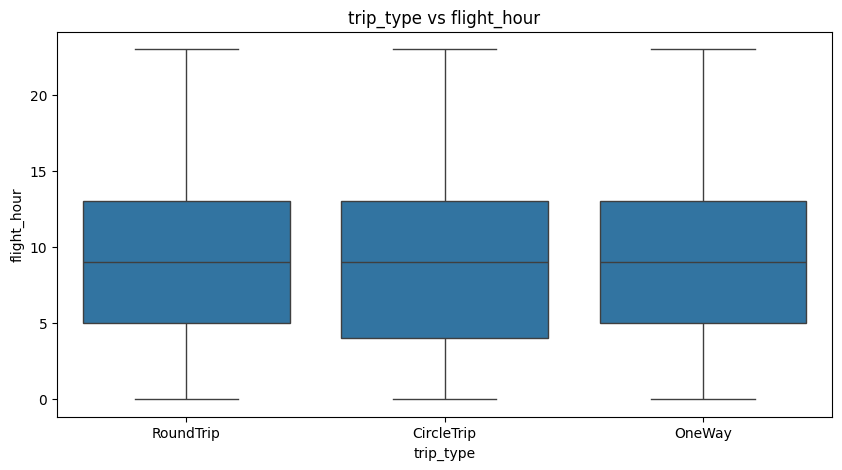

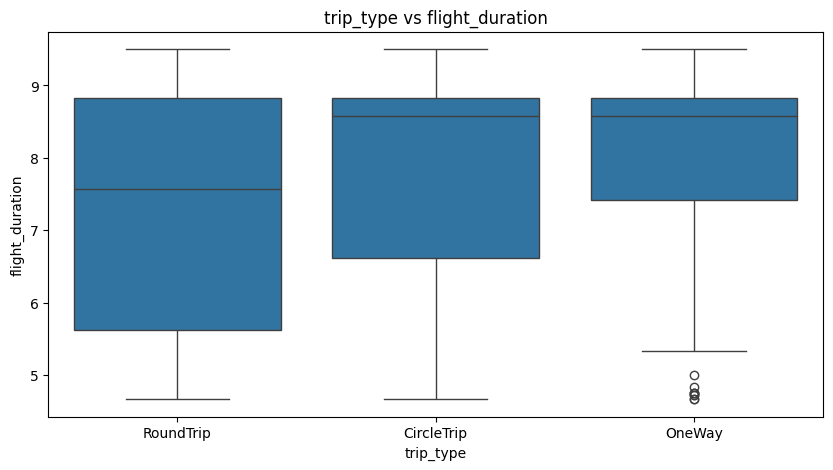

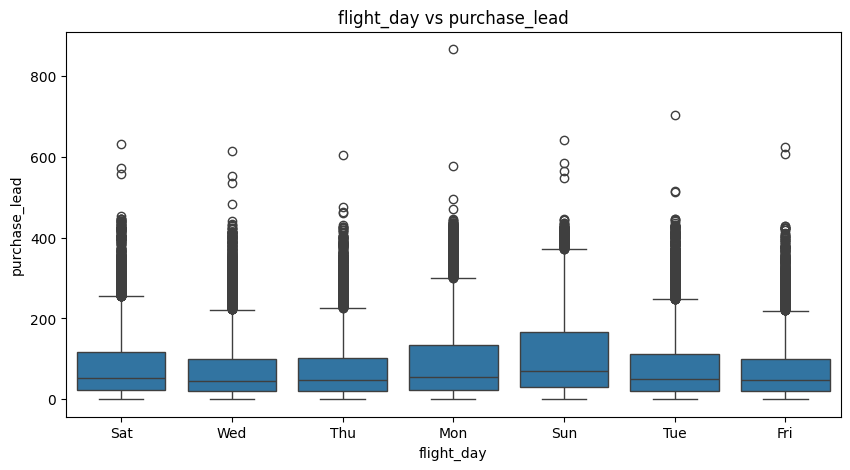

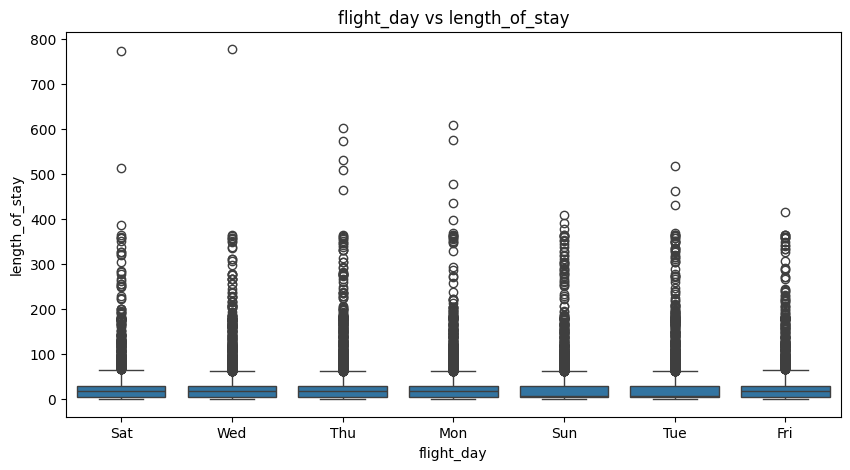

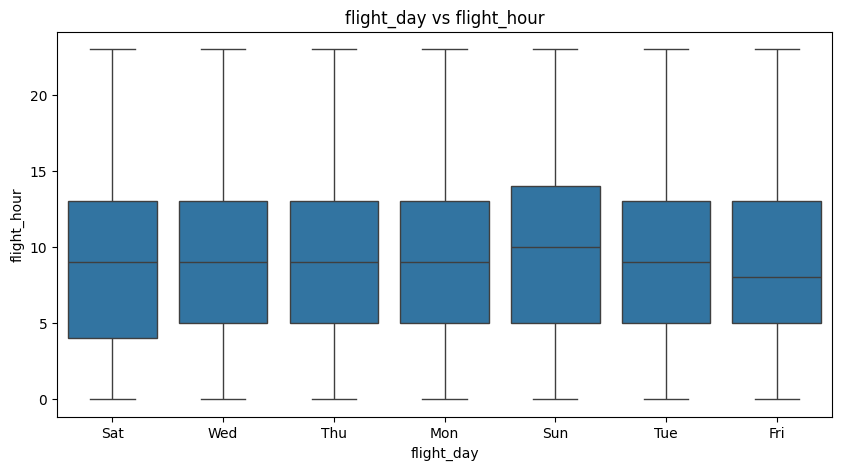

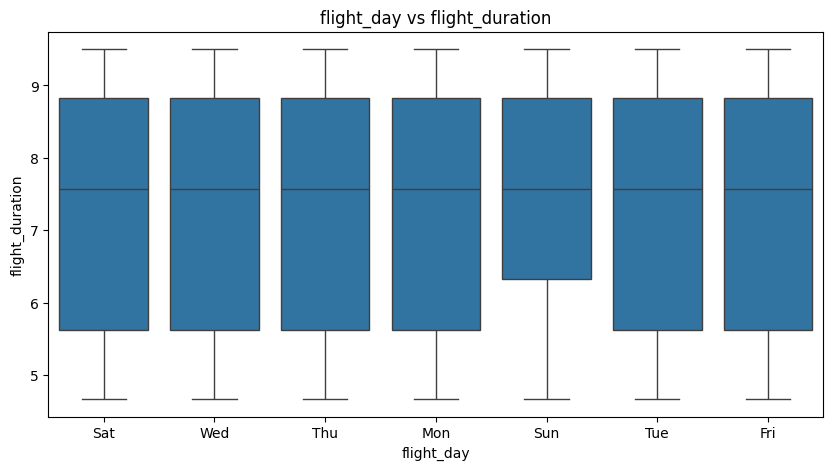

In [ ]:
for cat in categorical:
    for con in continuous:
        plt.figure(figsize=(10,5))
        sns.boxplot(x=df[cat], y=df[con])
        plt.title(f'{cat} vs {con}')
        plt.show()

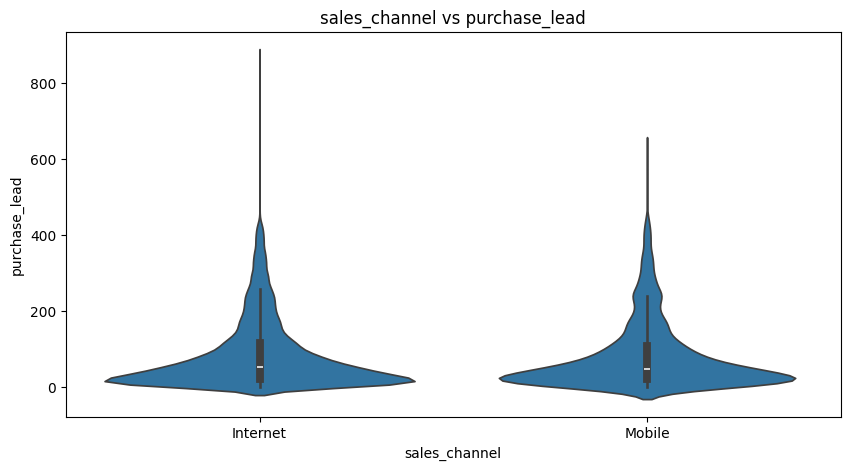

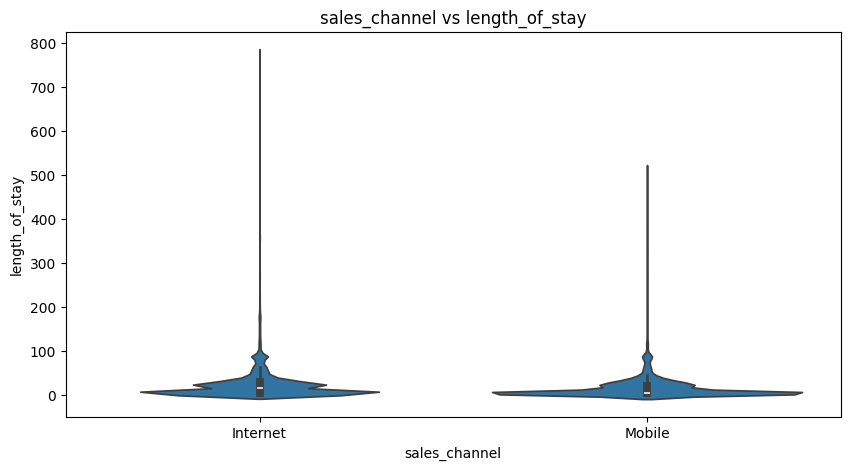

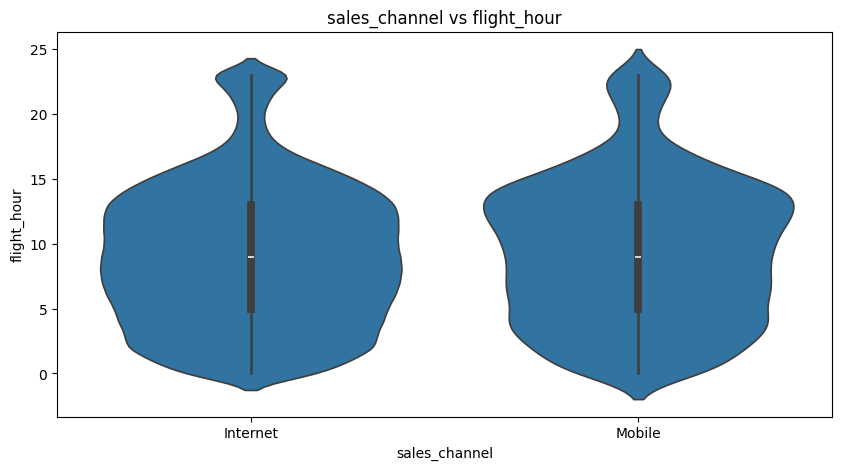

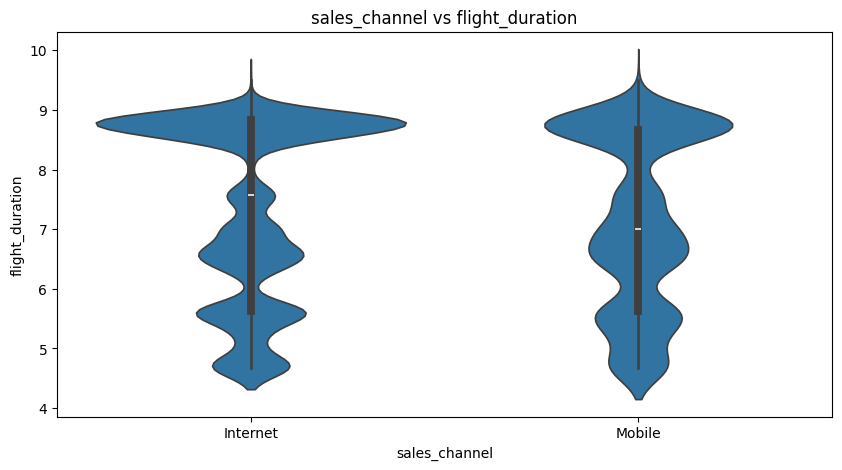

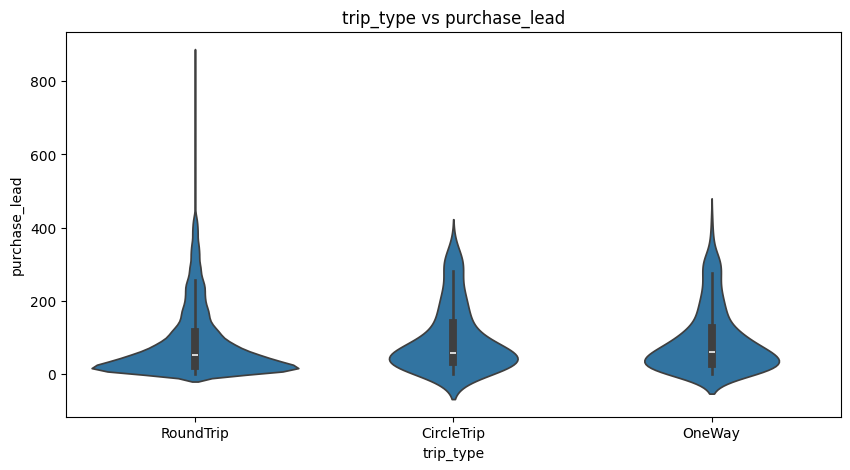

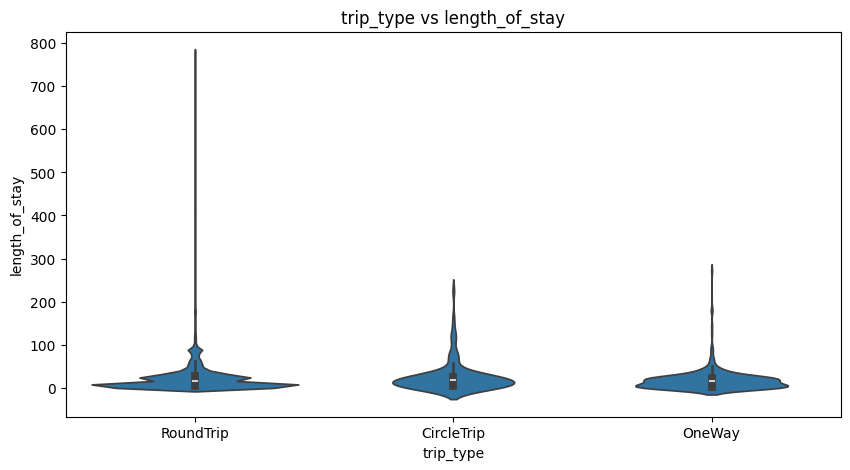

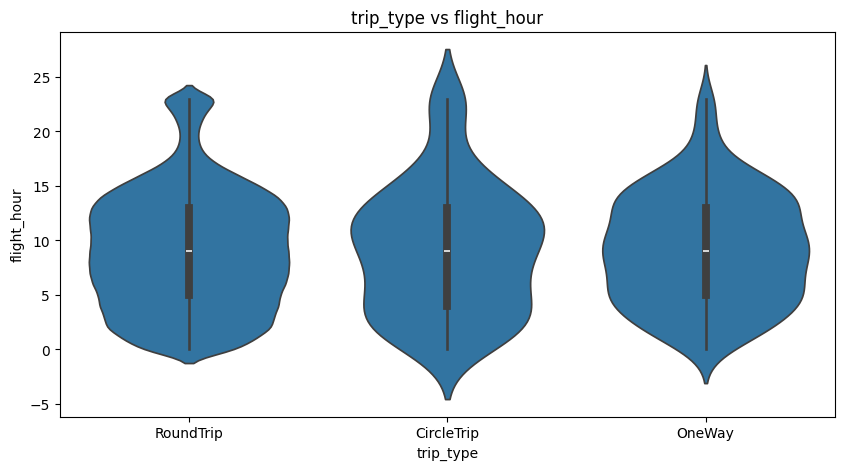

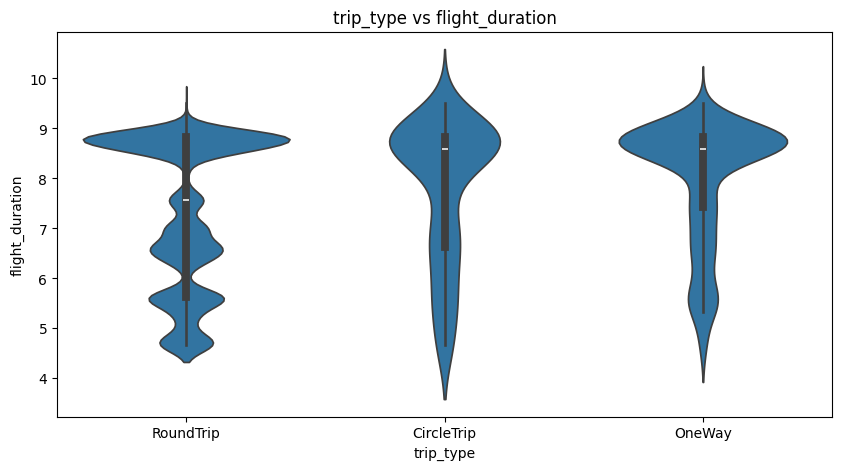

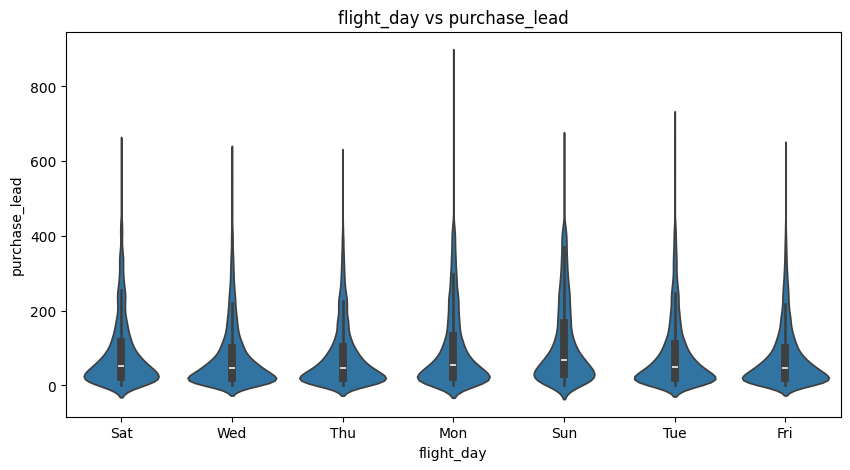

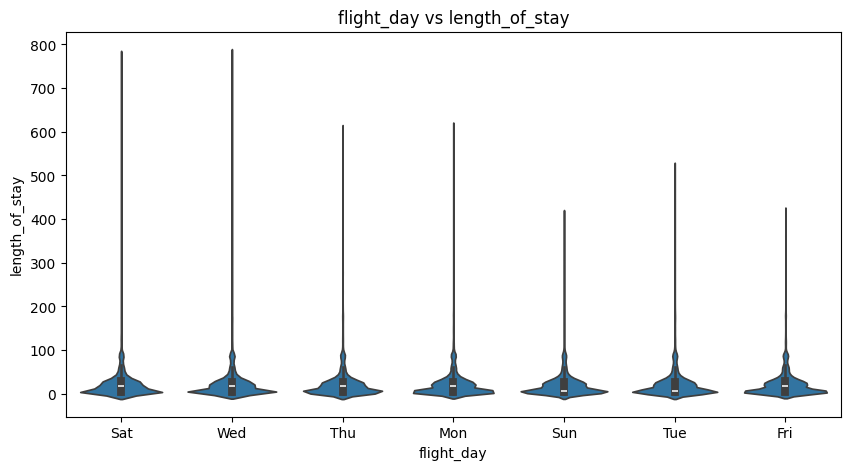

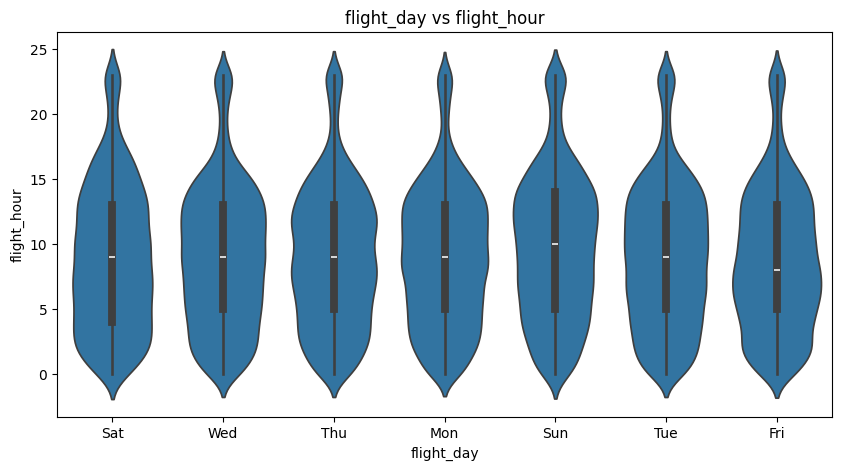

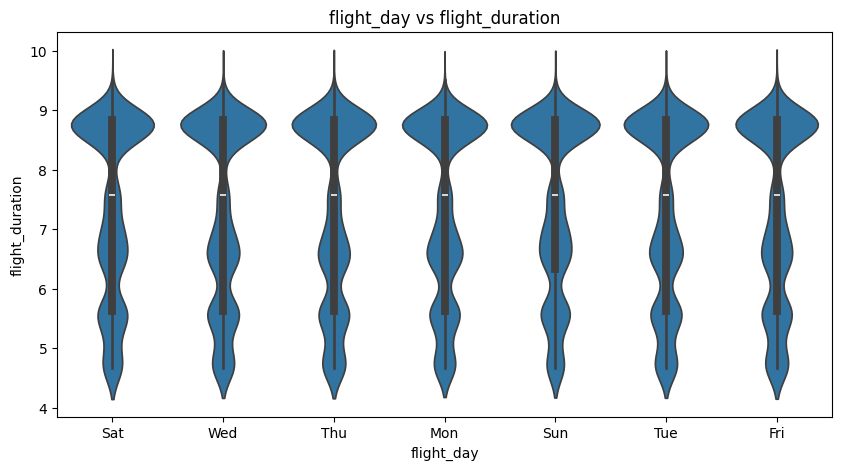

In [ ]:
for cat in categorical:
    for con in continuous:
        plt.figure(figsize=(10,5))
        sns.violinplot(x=df[cat], y=df[con])
        plt.title(f'{cat} vs {con}')
        plt.show()

In [ ]:
for cat in categorical:
    for con in continuous:
        plt.figure(figsize=(10,5))
        sns.swarmplot(x=df[cat], y=df[con])
        plt.title(f'{cat} vs {con}')
        plt.show()

In [ ]:
for cat in categorical:
    for con in continuous:
        plt.figure(figsize=(10,5))
        sns.stripplot(x=df[cat], y=df[con], jitter=True)
        plt.title(f'{cat} vs {con}')
        plt.show()

In [ ]:
for cat in categorical:
    for con in continuous:
        plt.figure(figsize=(10,5))
        for c in df[cat].unique():
            sns.kdeplot(df[df[cat]==c][con], label=str(c), fill=True)
        plt.title(f'{cat} vs {con}')
        plt.legend()
        plt.show()

In [ ]:
for cat in categorical:
    for con in continuous:
        plt.figure(figsize=(10,5))
        for c in df[cat].unique():
            sns.histplot(df[df[cat]==c][con], kde=True, label=str(c), element='step')
        plt.title(f'{cat} vs {con}')
        plt.legend()
        plt.show()

In [ ]:
for cat in discrete:
    for con in continuous:
        plt.figure(figsize=(10,5))
        sns.boxplot(x=df[cat], y=df[con])
        plt.title(f'{cat} vs {con}')
        plt.show()

In [ ]:
for cat in discrete:
    for con in continuous:
        plt.figure(figsize=(10,5))
        sns.violinplot(x=df[cat], y=df[con])
        plt.title(f'{cat} vs {con}')
        plt.show()

In [ ]:
for cat in discrete:
    for con in continuous:
        plt.figure(figsize=(10,5))
        for c in df[cat].unique():
            sns.kdeplot(df[df[cat]==c][con], label=str(c), fill=True)
        plt.title(f'{cat} vs {con}')
        plt.legend()
        plt.show()

In [ ]:
for cat in discrete:
    for con in continuous:
        plt.figure(figsize=(10,5))
        for c in df[cat].unique():
            sns.histplot(df[df[cat]==c][con], kde=True, label=str(c), element='step')
        plt.title(f'{cat} vs {con}')
        plt.legend()
        plt.show()

In [ ]:
group_mean = df.groupby('booking_complete')[['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']].mean()
print(group_mean)

In [ ]:
pivot_mean = df.pivot_table(values=['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration'], index='booking_complete', aggfunc='mean')
print(pivot_mean)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df1 = pd.get_dummies(df, columns = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin'], drop_first = True)

In [ ]:
df1.shape

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
continous = df1[['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']]

In [ ]:
scaler = StandardScaler()
continous = scaler.fit_transform(continous)

In [ ]:
df1 = df1.drop(['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration'], axis = 1)

In [ ]:
continuous

In [ ]:
columns = ['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']

In [ ]:
df2 = pd.DataFrame(continous, columns=columns)

In [ ]:
df_final = pd.concat([
    df1.reset_index(drop=True),
    df2.reset_index(drop=True)
], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler

In [ ]:
X = df_final.drop('booking_complete', axis=1)
y = df_final['booking_complete']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [ ]:
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [ ]:
X = df_final.drop(['booking_complete'], axis = 1)
y = df_final['booking_complete']

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Logistic regression")
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n",report)